In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 1 │ Imports & Configuration
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.linalg import cho_factor, cho_solve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── 30 NYSE Stocks across 10 sectors + 5 FX pairs ─────────────────────────────
SECTOR_MAP = {
    # Technology (5)
    'AAPL':'Technology',   'MSFT':'Technology',   'GOOGL':'Technology',
    'NVDA':'Technology',   'IBM': 'Technology',
    # Healthcare (4)
    'JNJ':'Healthcare',    'PFE':'Healthcare',
    'UNH':'Healthcare',    'ABT':'Healthcare',
    # Financials (4)
    'JPM':'Financials',    'BAC':'Financials',
    'GS': 'Financials',    'BLK':'Financials',
    # Energy (3)
    'XOM':'Energy',        'CVX':'Energy',        'COP':'Energy',
    # Consumer Discretionary (3)
    'AMZN':'Cons. Disc.',  'HD': 'Cons. Disc.',   'MCD':'Cons. Disc.',
    # Consumer Staples (3)
    'PG':'Cons. Stap.',    'KO': 'Cons. Stap.',   'WMT':'Cons. Stap.',
    # Industrials (3)
    'GE':'Industrials',    'CAT':'Industrials',   'BA': 'Industrials',
    # Materials (2)
    'LIN':'Materials',     'NEM':'Materials',
    # Real Estate (2)
    'PLD':'Real Estate',   'AMT':'Real Estate',
    # Utilities (1)
    'NEE':'Utilities',
    # FX Pairs — USD-denominated (5)
    'EURUSD=X':'Currency', 'GBPUSD=X':'Currency', 'AUDUSD=X':'Currency',
    'JPYUSD=X':'Currency', 'CHFUSD=X':'Currency',
}

UNIVERSE  = list(SECTOR_MAP.keys())
BENCHMARK = 'SPY'

TRAIN_START, TRAIN_END = '2015-01-01', '2023-12-31'
TEST_START,  TEST_END  = '2024-01-01', '2025-12-31'

SECTOR_COLORS = {
    'Technology' :'#1565C0', 'Healthcare'  :'#2E7D32', 'Financials'  :'#E65100',
    'Energy'     :'#B71C1C', 'Cons. Disc.' :'#6A1B9A', 'Cons. Stap.' :'#00695C',
    'Industrials':'#4E342E', 'Materials'   :'#9E9D24', 'Real Estate' :'#AD1457',
    'Utilities'  :'#0277BD', 'Currency'    :'#37474F',
}

def pretty(t):
    """'EURUSD=X' → 'EUR',  'AAPL' → 'AAPL'"""
    return t.replace('USD=X', '').replace('=X', '')

print(f"Universe  : {sum(v != 'Currency' for v in SECTOR_MAP.values())} stocks "
      f"+ {sum(v == 'Currency' for v in SECTOR_MAP.values())} FX = {len(UNIVERSE)} assets")
print(f"Benchmark : {BENCHMARK}")
print(f"Training  : {TRAIN_START}  →  {TRAIN_END}")
print(f"Testing   : {TEST_START}   →  {TEST_END}")

Universe  : 30 stocks + 5 FX = 35 assets
Benchmark : SPY
Training  : 2015-01-01  →  2023-12-31
Testing   : 2024-01-01   →  2025-12-31


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 2 │ Download Price Data
# ═══════════════════════════════════════════════════════════════════════════════
print("Downloading from Yahoo Finance …")

raw = yf.download(
    UNIVERSE + [BENCHMARK],
    start=TRAIN_START, end=TEST_END,
    auto_adjust=True, progress=False
)['Close']

# Drop any ticker with >10% missing values; forward-fill the rest
raw = raw.dropna(axis=1, thresh=int(0.90 * len(raw))).ffill().dropna()

spy_prices   = raw[BENCHMARK]
asset_prices = raw.drop(columns=[BENCHMARK])

# Only keep tickers that survived cleaning
tickers = [t for t in UNIVERSE if t in asset_prices.columns]
asset_prices = asset_prices[tickers]

dropped = set(UNIVERSE) - set(tickers)
print(f"Assets retained : {len(tickers)}")
print(f"Dropped         : {dropped if dropped else 'none'}")
print(f"Date range      : {asset_prices.index[0].date()}  →  {asset_prices.index[-1].date()}")

Assets retained : 35
Dropped         : none
Date range      : 2015-01-02  →  2025-12-30


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 3 │ ADMM — Equal Risk Contribution Solver
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Objective:  min  (½)x'Σx  −  Σ ln(zᵢ)      s.t.  x = z
#  ─────────────────────────────────────────────────────────────────────────────
#  ADMM splits the smooth quadratic (on x) from the log-barrier (on z):
#
#  ┌─ x-update ─────────────────────────────────────────────────────────────┐
#  │  Solve the linear system:  (Σ + ρI) x  =  ρz − y                     │
#  │  ✦ Cholesky-factor (Σ + ρI) ONCE before the loop  →  O(N³)           │
#  │  ✦ Each iteration: only a triangular solve         →  O(N²)           │
#  └────────────────────────────────────────────────────────────────────────┘
#
#  ┌─ z-update ─────────────────────────────────────────────────────────────┐
#  │  Each zᵢ is independent; FOC gives a quadratic:                       │
#  │      ρzᵢ² − bᵢ zᵢ − 1 = 0,   where  bᵢ = ρxᵢ + yᵢ                 │
#  │  Closed-form positive root:   zᵢ = (bᵢ + √(bᵢ² + 4ρ)) / (2ρ)       │
#  │  ✦ O(N) element-wise — no solver needed                               │
#  └────────────────────────────────────────────────────────────────────────┘
#
#  ┌─ y-update ─────────────────────────────────────────────────────────────┐
#  │  Dual ascent:   y  ←  y + ρ(x − z)                                   │
#  └────────────────────────────────────────────────────────────────────────┘
#
#  Convergence: both primal ‖x−z‖ and dual ‖ρ(z_new−z_old)‖ < tol
# ═══════════════════════════════════════════════════════════════════════════════

def admm_erc(Sigma, rho=1.0, max_iter=1000, tol=1e-6, verbose=True):
    N = Sigma.shape[0]

    # Small ridge for numerical stability (does not affect ERC solution)
    Sigma_reg = Sigma + 1e-6 * np.eye(N)

    # ── Pre-factor (Σ + ρI) — done ONCE, reused every iteration ──────────────
    A = Sigma_reg + rho * np.eye(N)
    c, lower = cho_factor(A)           # O(N³) — the only cubic cost

    # Initialise at equal-weight
    x = np.ones(N) / N
    z = np.ones(N) / N
    y = np.zeros(N)

    for k in range(max_iter):
        z_old = z.copy()

        # x-update: linear system  →  O(N²) per iteration
        x = cho_solve((c, lower), rho * z - y)

        # z-update: closed-form quadratic root  →  O(N) per iteration
        b = rho * x + y
        z = (b + np.sqrt(b**2 + 4.0 * rho)) / (2.0 * rho)

        # y-update: dual ascent
        y = y + rho * (x - z)

        # ── Convergence check ──────────────────────────────────────────────────
        primal_res = np.linalg.norm(x - z)               # feasibility: x = z?
        dual_res   = np.linalg.norm(rho * (z - z_old))   # optimality: z stable?

        if verbose and (k + 1) % 200 == 0:
            print(f"  iter {k+1:4d}  │  primal={primal_res:.2e}  dual={dual_res:.2e}")

        if primal_res < tol and dual_res < tol:
            if verbose:
                print(f"  ✓  Converged at iteration {k+1}  "
                      f"(primal={primal_res:.2e}, dual={dual_res:.2e})")
            break

    # Normalise → portfolio weights sum to 1
    w = x / x.sum()
    return w


def risk_contributions(w, cov):
    """
    Fractional risk contribution of each asset:
        RC_i = wᵢ · (Σw)ᵢ / √(w'Σw)    [vector sums to 1]
    """
    w   = np.asarray(w, float)
    vol = np.sqrt(w @ cov @ w)
    rc  = w * (cov @ w / vol)
    return rc / rc.sum()


print("ADMM solver ready.")
print("  Complexity:  O(N³) setup  +  O(N²) per iteration  +  O(N) z-update")

ADMM solver ready.
  Complexity:  O(N³) setup  +  O(N²) per iteration  +  O(N) z-update


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 4 │ Estimate Covariance on Training Data → Solve ADMM
# ═══════════════════════════════════════════════════════════════════════════════

# ── Log returns  (ln(Pₜ / Pₜ₋₁)) ────────────────────────────────────────────
train_log = np.log(asset_prices[TRAIN_START:TRAIN_END] /
                   asset_prices[TRAIN_START:TRAIN_END].shift(1)).dropna()
test_log  = np.log(asset_prices[TEST_START:TEST_END] /
                   asset_prices[TEST_START:TEST_END].shift(1)).dropna()

spy_log  = np.log(spy_prices / spy_prices.shift(1)).dropna()
spy_test = spy_log[TEST_START:TEST_END].reindex(test_log.index).fillna(0)

n = len(tickers)
print(f"Training : {len(train_log):,} days  │  {TRAIN_START}  →  {TRAIN_END}")
print(f"Testing  : {len(test_log):,} days  │  {TEST_START}  →  {TEST_END}")
print(f"Assets   : {n}\n")

# ── Annualised sample covariance from training log-returns ────────────────────
Sigma_train = train_log.cov().values * 252

# ── Solve ERC via ADMM ────────────────────────────────────────────────────────
print("── ADMM Optimisation ──────────────────────────────────────────────────")
w_erc   = admm_erc(Sigma_train, rho=1.0, max_iter=1000, tol=1e-6, verbose=True)
w_naive = np.ones(n) / n

# ── Risk contributions (training universe) ────────────────────────────────────
rc_erc   = risk_contributions(w_erc,   Sigma_train)
rc_naive = risk_contributions(w_naive, Sigma_train)

max_rc_diff = rc_erc.max() - rc_erc.min()
print(f"\nRC uniformity check — max − min : {max_rc_diff:.2e}   (→ 0 = perfect ERC)")

# ── Weight & RC summary table ─────────────────────────────────────────────────
summary = pd.DataFrame({
    'Label'      : [pretty(t) for t in tickers],
    'Sector'     : [SECTOR_MAP.get(t, '?') for t in tickers],
    'ERC Wt (%)' : np.round(w_erc   * 100, 3),
    '1/N Wt (%)' : np.round(w_naive * 100, 3),
    'RC ERC (%)' : np.round(rc_erc  * 100, 3),
    'RC 1/N (%)' : np.round(rc_naive * 100, 3),
}).sort_values('ERC Wt (%)', ascending=False).reset_index(drop=True)

print("\n" + summary.to_string(index=False))

Training : 2,345 days  │  2015-01-01  →  2023-12-31
Testing  : 518 days  │  2024-01-01  →  2025-12-31
Assets   : 35

── ADMM Optimisation ──────────────────────────────────────────────────
  iter  200  │  primal=8.13e-06  dual=4.24e-04
  iter  400  │  primal=6.52e-08  dual=3.44e-06
  ✓  Converged at iteration 452  (primal=1.89e-08, dual=9.98e-07)

RC uniformity check — max − min : 1.76e-06   (→ 0 = perfect ERC)

Label      Sector  ERC Wt (%)  1/N Wt (%)  RC ERC (%)  RC 1/N (%)
  JPY    Currency      11.538       2.857       2.857       0.091
  EUR    Currency      10.154       2.857       2.857       0.106
  CHF    Currency       9.909       2.857       2.857       0.075
  GBP    Currency       9.527       2.857       2.857       0.120
  AUD    Currency       8.204       2.857       2.857       0.191
  WMT Cons. Stap.       2.759       2.857       2.857       1.758
  NEM   Materials       2.538       2.857       2.857       1.714
  JNJ  Healthcare       2.442       2.857       2.857   

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 5 │ Backtest (Jan 2023 – Dec 2025) + Risk Metrics
# ═══════════════════════════════════════════════════════════════════════════════

# ── Daily log-returns for each strategy (fixed weights from training) ─────────
port_erc   = (test_log[tickers] @ w_erc).values
port_naive = (test_log[tickers] @ w_naive).values
port_spy   = spy_test.values
dates      = test_log.index

# ── Cumulative wealth:  exp(Σ rₜ)  ───────────────────────────────────────────
cum_erc   = np.exp(np.cumsum(port_erc))
cum_naive = np.exp(np.cumsum(port_naive))
cum_spy   = np.exp(np.cumsum(port_spy))

# ── Annual log-returns by calendar year ───────────────────────────────────────
def annual_log_ret(r, idx):
    s = pd.Series(r, index=idx)
    return s.groupby(s.index.year).sum().apply(np.expm1)   # → simple return

ann_erc   = annual_log_ret(port_erc,   dates)
ann_naive = annual_log_ret(port_naive, dates)
ann_spy   = annual_log_ret(port_spy,   dates)

# ── Risk metric calculator ────────────────────────────────────────────────────
def compute_metrics(r, label, rf=0.05):
    T       = len(r)
    ann_ret = np.expm1(r.sum() * 252 / T)            # geometric annualised return
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = (ann_ret - rf) / ann_vol

    neg_r   = r[r < 0]
    sortino = (ann_ret - rf) / (neg_r.std() * np.sqrt(252))

    cum     = np.exp(np.cumsum(r))
    peak    = np.maximum.accumulate(cum)
    mdd     = ((cum - peak) / peak).min()
    calmar  = ann_ret / abs(mdd)

    var95   = np.percentile(r, 5)                     # 95% daily VaR (hist.)
    cvar95  = r[r <= var95].mean()                    # Expected Shortfall
    hit     = (r > 0).mean()                          # % profitable days

    return {
        'Strategy'         : label,
        'Ann. Return'      : f"{ann_ret*100:+.2f}%",
        'Ann. Volatility'  : f"{ann_vol*100:.2f}%",
        'Sharpe Ratio'     : f"{sharpe:.3f}",
        'Sortino Ratio'    : f"{sortino:.3f}",
        'Max Drawdown'     : f"{mdd*100:.2f}%",
        'Calmar Ratio'     : f"{calmar:.3f}",
        'VaR 95% (daily)'  : f"{var95*100:.2f}%",
        'CVaR 95% (daily)' : f"{cvar95*100:.2f}%",
        'Hit Rate'         : f"{hit*100:.1f}%",
    }

metrics_df = pd.DataFrame([
    compute_metrics(port_erc,   'ERC (ADMM)'),
    compute_metrics(port_naive, 'Naive 1/N'),
    compute_metrics(port_spy,   'S&P 500 (SPY)'),
])

print("═" * 82)
print("  RISK METRICS │ Out-of-Sample Test Period  (Jan 2023 – Dec 2025)")
print("═" * 82)
print(metrics_df.to_string(index=False))
print("═" * 82)

══════════════════════════════════════════════════════════════════════════════════
  RISK METRICS │ Out-of-Sample Test Period  (Jan 2023 – Dec 2025)
══════════════════════════════════════════════════════════════════════════════════
     Strategy Ann. Return Ann. Volatility Sharpe Ratio Sortino Ratio Max Drawdown Calmar Ratio VaR 95% (daily) CVaR 95% (daily) Hit Rate
   ERC (ADMM)      +9.28%           7.04%        0.608         0.908       -8.03%        1.156          -0.63%           -0.92%    55.0%
    Naive 1/N     +16.15%          11.01%        1.013         1.245      -12.93%        1.249          -0.96%           -1.59%    57.7%
S&P 500 (SPY)     +21.06%          16.00%        1.004         1.226      -18.76%        1.123          -1.54%           -2.38%    56.2%
══════════════════════════════════════════════════════════════════════════════════


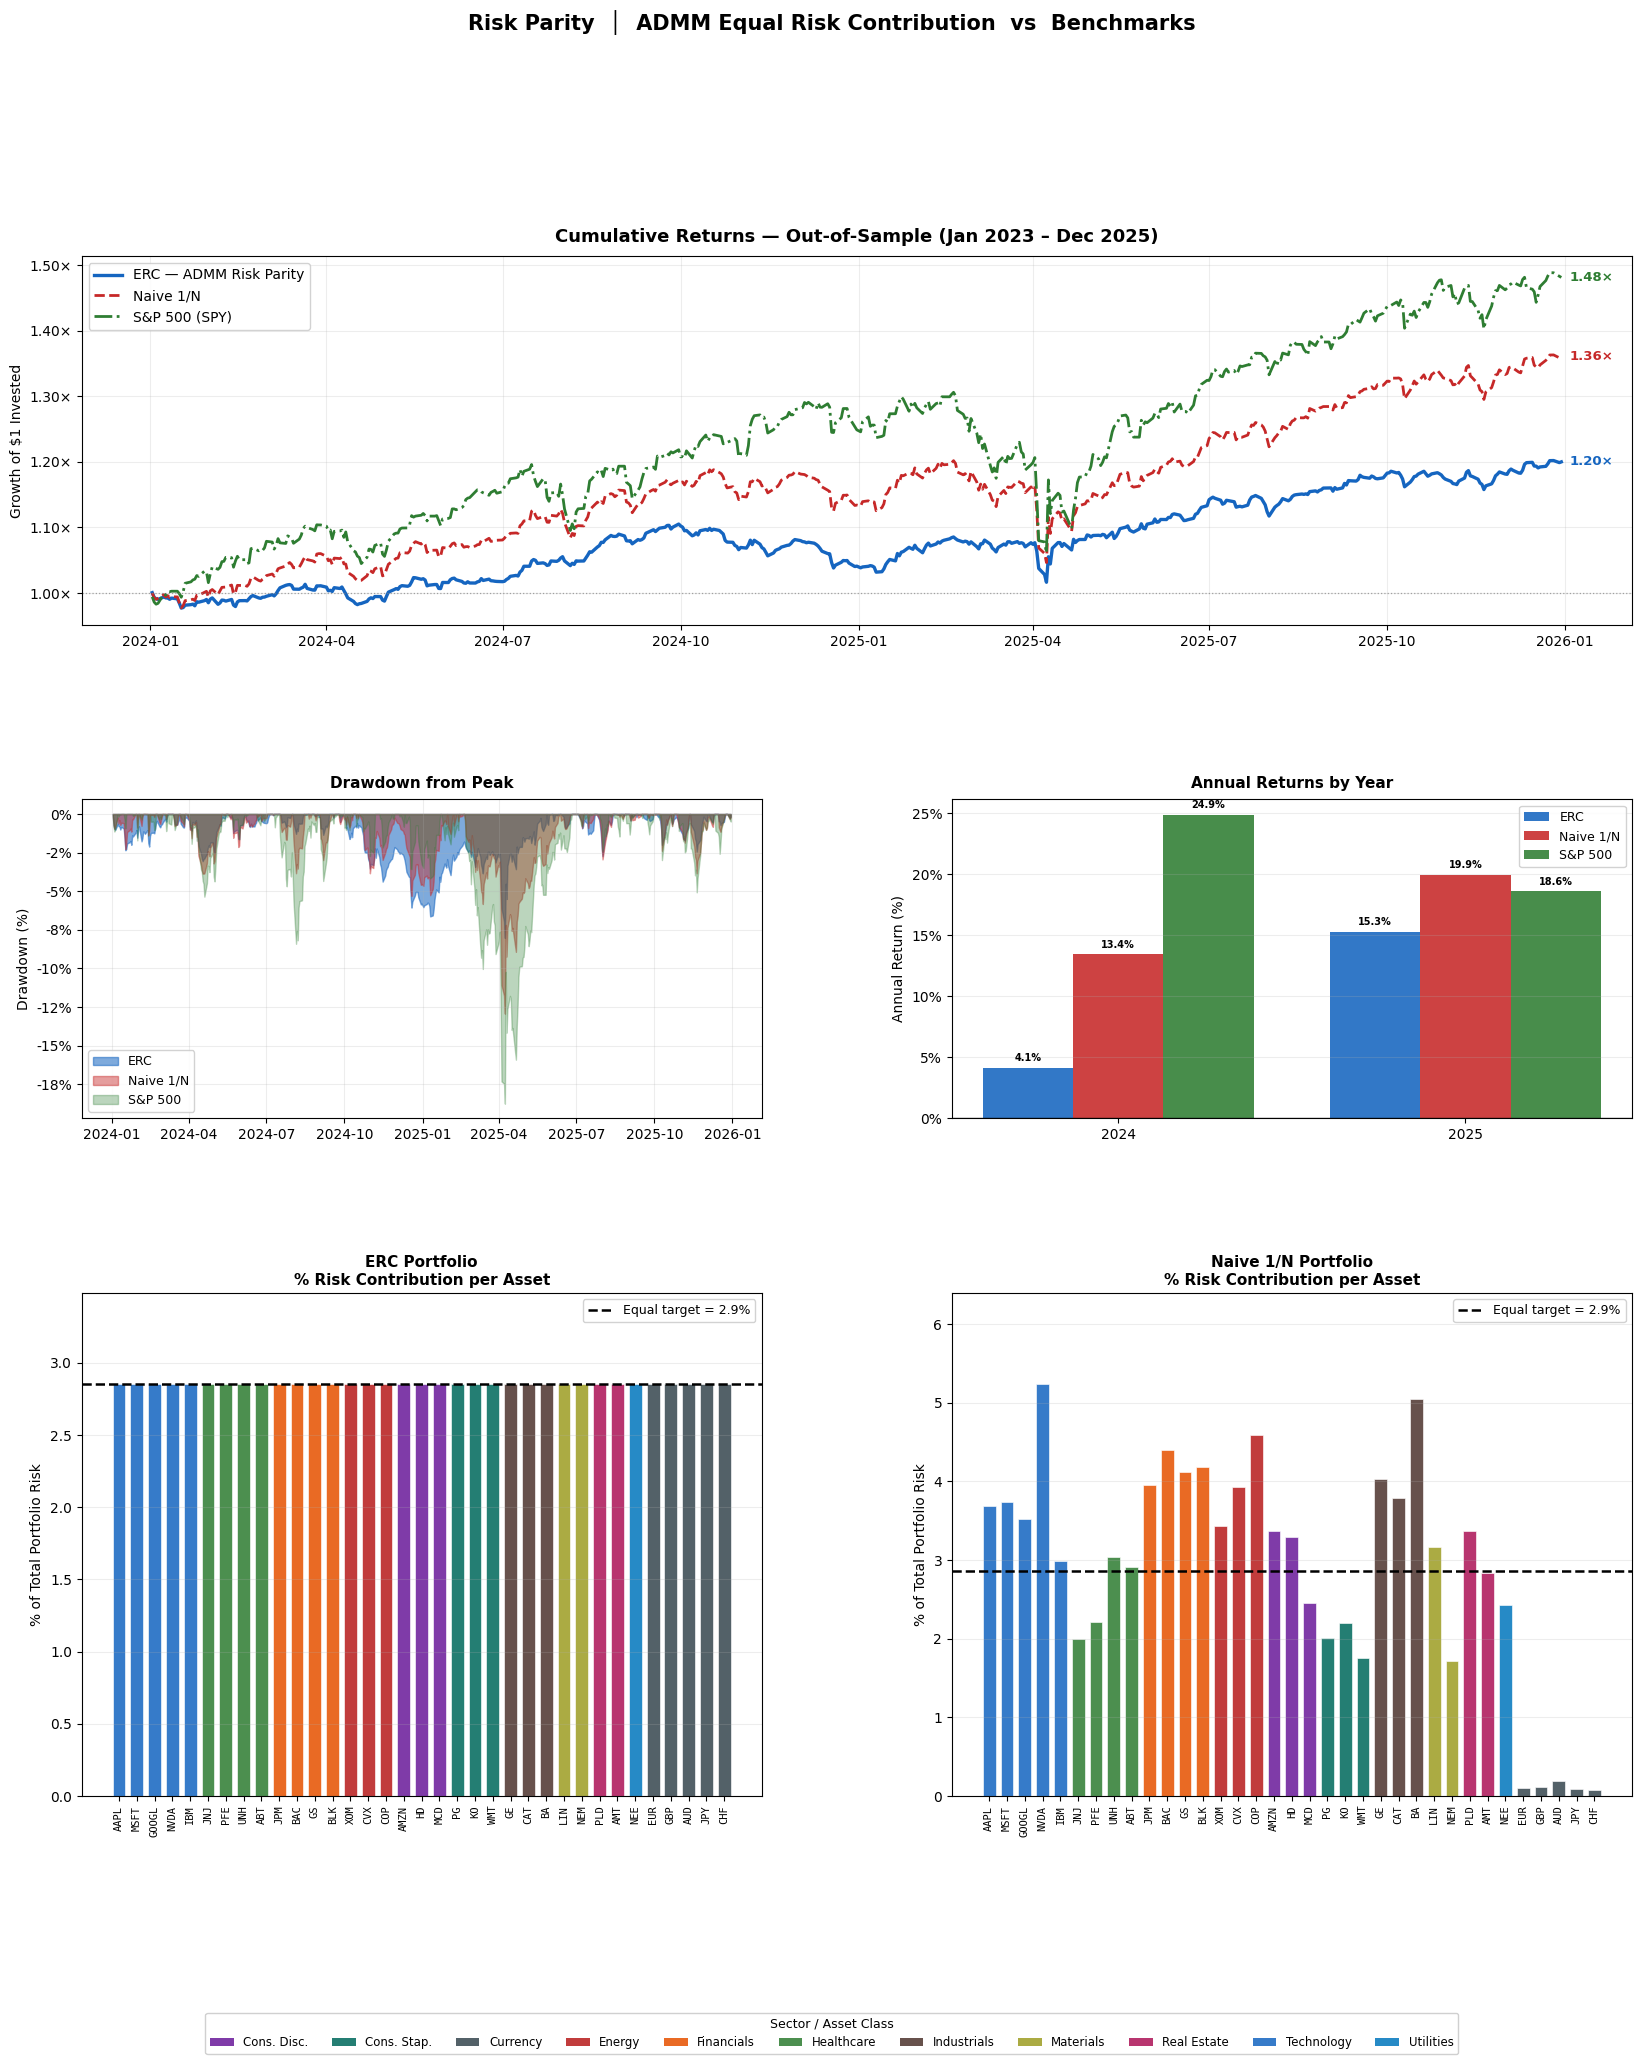

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 6 │ Visualisation  (5-panel figure)
# ═══════════════════════════════════════════════════════════════════════════════

C      = {'erc':'#1565C0', 'naive':'#C62828', 'spy':'#2E7D32'}
labels = [pretty(t) for t in tickers]
bcols  = [SECTOR_COLORS.get(SECTOR_MAP.get(t, 'Currency'), '#9E9E9E') for t in tickers]

def dd_pct(r):
    """Drawdown curve in %"""
    cum  = np.exp(np.cumsum(r))
    peak = np.maximum.accumulate(cum)
    return (cum / peak - 1) * 100

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig,
                         hspace=0.44, wspace=0.28,
                         height_ratios=[1.1, 0.95, 1.5])

# ── Panel 1: Cumulative Returns (full width) ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates, cum_erc,   lw=2.4, color=C['erc'],   label='ERC — ADMM Risk Parity')
ax1.plot(dates, cum_naive, lw=2.0, color=C['naive'],  label='Naive 1/N',          ls='--')
ax1.plot(dates, cum_spy,   lw=2.0, color=C['spy'],    label='S&P 500 (SPY)',       ls='-.')
ax1.axhline(1.0, color='grey', lw=0.9, ls=':', alpha=0.7)

# Annotate final values on the right edge
for cum, col in [(cum_erc, C['erc']), (cum_naive, C['naive']), (cum_spy, C['spy'])]:
    ax1.annotate(f"{cum[-1]:.2f}×",
                 xy=(dates[-1], cum[-1]), xytext=(6, 0),
                 textcoords='offset points',
                 color=col, fontsize=9.5, fontweight='bold', va='center')

ax1.set_ylabel('Growth of $1 Invested', fontsize=10)
ax1.set_title('Cumulative Returns — Out-of-Sample (Jan 2023 – Dec 2025)',
              fontsize=13, fontweight='bold', pad=10)
ax1.legend(fontsize=10, loc='upper left', framealpha=0.88)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}×"))
ax1.grid(True, alpha=0.22)

# ── Panel 2: Drawdown ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(dates, dd_pct(port_erc),   color=C['erc'],   alpha=0.55, label='ERC')
ax2.fill_between(dates, dd_pct(port_naive), color=C['naive'], alpha=0.45, label='Naive 1/N')
ax2.fill_between(dates, dd_pct(port_spy),   color=C['spy'],   alpha=0.32, label='S&P 500')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax2.set_title('Drawdown from Peak', fontsize=11, fontweight='bold', pad=8)
ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.88)
ax2.grid(True, alpha=0.22)

# ── Panel 3: Annual Returns by Year ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
years = sorted(set(ann_erc.index) | set(ann_naive.index) | set(ann_spy.index))
x_pos = np.arange(len(years))
w_bar = 0.26

bars_erc   = ax3.bar(x_pos - w_bar, ann_erc.reindex(years).values   * 100,
                      w_bar, color=C['erc'],   label='ERC',       alpha=0.88)
bars_naive = ax3.bar(x_pos,          ann_naive.reindex(years).values * 100,
                      w_bar, color=C['naive'], label='Naive 1/N', alpha=0.88)
bars_spy   = ax3.bar(x_pos + w_bar, ann_spy.reindex(years).values   * 100,
                      w_bar, color=C['spy'],   label='S&P 500',   alpha=0.88)

# Label each bar with its value
for bars in [bars_erc, bars_naive, bars_spy]:
    for bar in bars:
        h = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width() / 2, h + (0.4 if h >= 0 else -1.2),
                 f"{h:.1f}%", ha='center', va='bottom', fontsize=7, fontweight='bold')

ax3.axhline(0, color='black', lw=0.9)
ax3.set_xticks(x_pos)
ax3.set_xticklabels([str(y) for y in years], fontsize=10)
ax3.set_ylabel('Annual Return (%)', fontsize=10)
ax3.set_title('Annual Returns by Year', fontsize=11, fontweight='bold', pad=8)
ax3.legend(fontsize=9, framealpha=0.88)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax3.grid(axis='y', alpha=0.22)

# ── Panel 4: ERC Risk Contributions ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(range(n), rc_erc * 100, color=bcols, alpha=0.86, width=0.72,
        edgecolor='white', linewidth=0.5)
ax4.axhline(100 / n, color='black', lw=1.8, ls='--',
            label=f'Equal target = {100/n:.1f}%')
ax4.set_xticks(range(n))
ax4.set_xticklabels(labels, rotation=90, fontsize=7.5, fontfamily='monospace')
ax4.set_ylabel('% of Total Portfolio Risk', fontsize=10)
ax4.set_title('ERC Portfolio\n% Risk Contribution per Asset',
              fontsize=11, fontweight='bold')
ax4.legend(fontsize=9, framealpha=0.88)
ax4.grid(axis='y', alpha=0.22)
ax4.set_ylim(0, rc_erc.max() * 100 * 1.22)

# ── Panel 5: 1/N Risk Contributions ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(range(n), rc_naive * 100, color=bcols, alpha=0.86, width=0.72,
        edgecolor='white', linewidth=0.5)
ax5.axhline(100 / n, color='black', lw=1.8, ls='--',
            label=f'Equal target = {100/n:.1f}%')
ax5.set_xticks(range(n))
ax5.set_xticklabels(labels, rotation=90, fontsize=7.5, fontfamily='monospace')
ax5.set_ylabel('% of Total Portfolio Risk', fontsize=10)
ax5.set_title('Naive 1/N Portfolio\n% Risk Contribution per Asset',
              fontsize=11, fontweight='bold')
ax5.legend(fontsize=9, framealpha=0.88)
ax5.grid(axis='y', alpha=0.22)
ax5.set_ylim(0, rc_naive.max() * 100 * 1.22)

# ── Shared sector / asset-class legend ────────────────────────────────────────
active = sorted({SECTOR_MAP.get(t, 'Currency') for t in tickers})
handles = [Patch(facecolor=SECTOR_COLORS[s], label=s, alpha=0.86) for s in active]
fig.legend(handles=handles, title='Sector / Asset Class',
           loc='lower center', ncol=len(active),
           fontsize=8.5, title_fontsize=9,
           bbox_to_anchor=(0.5, -0.022), framealpha=0.92)

plt.suptitle('Risk Parity  │  ADMM Equal Risk Contribution  vs  Benchmarks',
             fontsize=15, fontweight='bold', y=1.003)

plt.show()